In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
df = pd.read_csv('week2.csv')
print(df.head())


   # id:19-19-19   Unnamed: 1  Unnamed: 2
0           -0.43       -0.21           1
1            0.49       -0.13           1
2            0.03        0.19           1
3            0.00        0.01           1
4           -0.85        0.02           1


In [4]:
X1 = df.iloc[:,0]
X2 = df.iloc[:,1]
y = df.iloc[:,2]
X = np.column_stack([X1, X2])


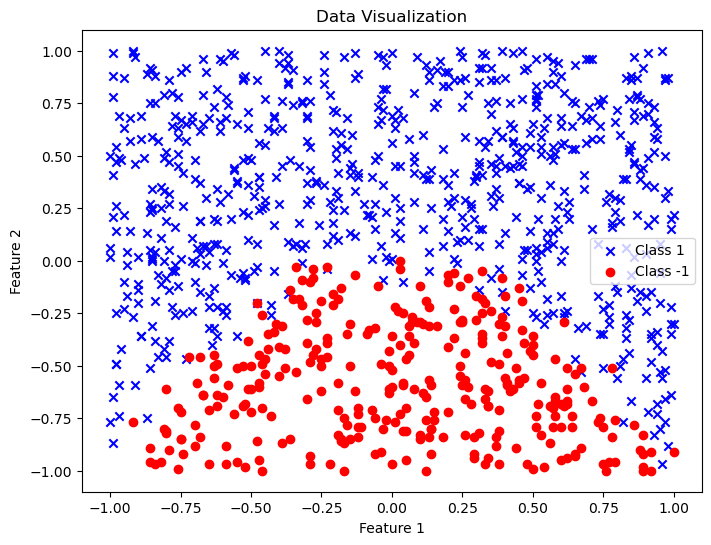

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(X1[y==1], X2[y==1], marker='x', color='blue', label='Class 1')
plt.scatter(X1[y==-1], X2[y==-1], marker='o', color='red', label='Class -1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Data Visualization')
plt.show()


In [6]:
!pip install scikit-learn


In [7]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X, y)
print('Model coefficients:', model.coef_)
print('Model intercept:', model.intercept_)


Model coefficients: [[0.21146321 5.34410595]]
Model intercept: [1.74907327]


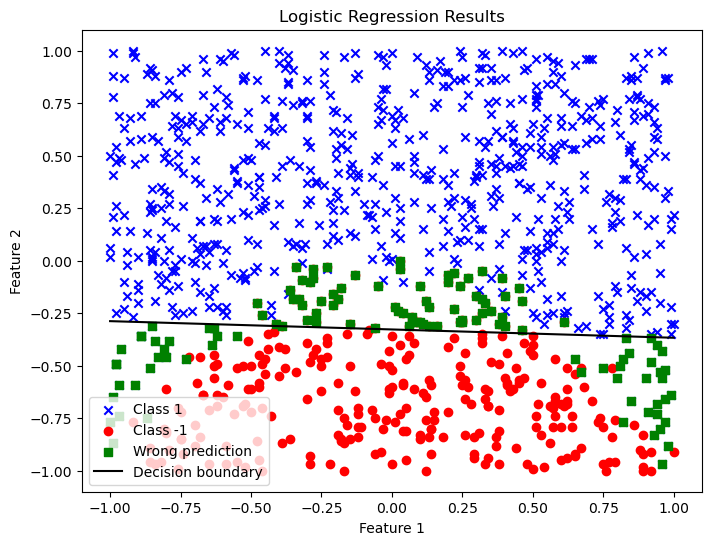

In [9]:
y_pred = model.predict(X)
plt.figure(figsize=(8,6))
plt.scatter(X1[y==1], X2[y==1], marker='x', color='blue', label='Class 1')
plt.scatter(X1[y==-1], X2[y==-1], marker='o', color='red', label='Class -1')
plt.scatter(X1[y_pred!=y], X2[y_pred!=y], marker='s', color='green', label='Wrong prediction')
# Decision boundary
coef = model.coef_[0]
intercept = model.intercept_[0]
x_vals = np.linspace(X1.min(), X1.max(), 100)
y_vals = -(coef[0]*x_vals + intercept)/coef[1]
plt.plot(x_vals, y_vals, color='black', label='Decision boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Logistic Regression Results')
plt.show()


In [10]:
from sklearn.svm import LinearSVC

In [11]:
svm1 = LinearSVC(C=0.001, max_iter=10000)
svm1.fit(X, y)

svm2 = LinearSVC(C=1, max_iter=10000)
svm2.fit(X, y)

svm3 = LinearSVC(C=100, max_iter=10000)
svm3.fit(X, y)


LinearSVC(C=100, max_iter=10000)

In [12]:
print('SVM (C=0.001): coef =', svm1.coef_, 'intercept =', svm1.intercept_)
print('SVM (C=1): coef =', svm2.coef_, 'intercept =', svm2.intercept_)
print('SVM (C=100): coef =', svm3.coef_, 'intercept =', svm3.intercept_)


SVM (C=0.001): coef = [[-0.00236389  0.47868761]] intercept = [0.23246842]
SVM (C=1): coef = [[0.07773562 1.96445837]] intercept = [0.63140823]
SVM (C=100): coef = [[0.08064668 1.9908474 ]] intercept = [0.64048386]


In [13]:
y_pred1 = svm1.predict(X)
y_pred2 = svm2.predict(X)
y_pred3 = svm3.predict(X)


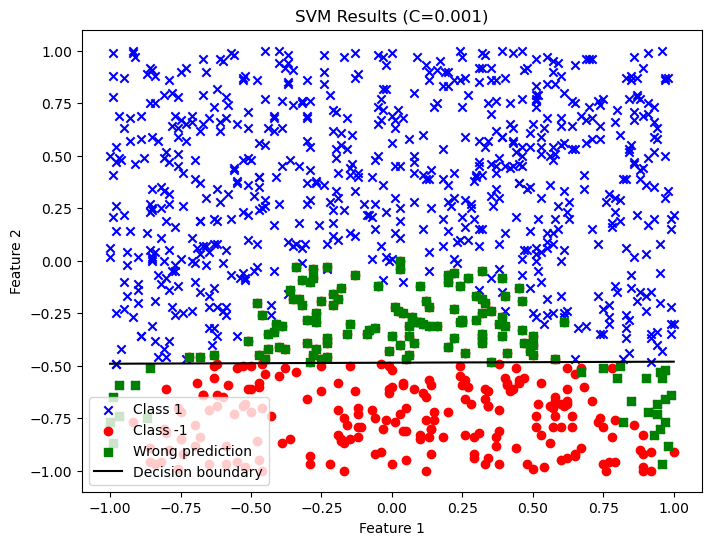

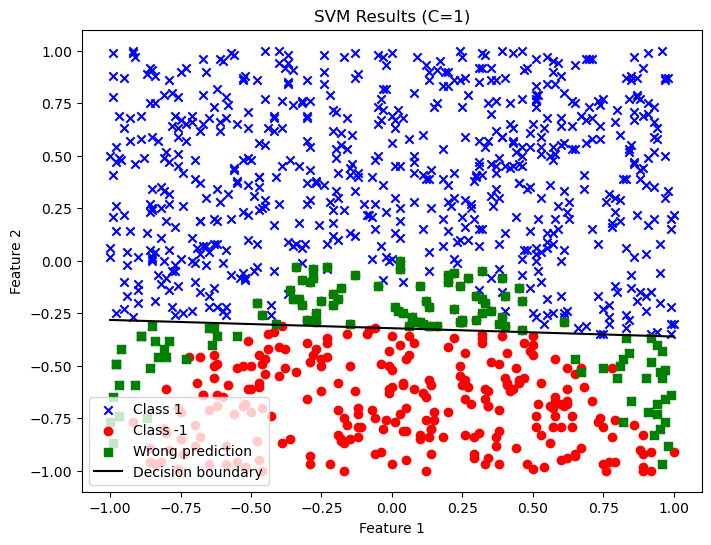

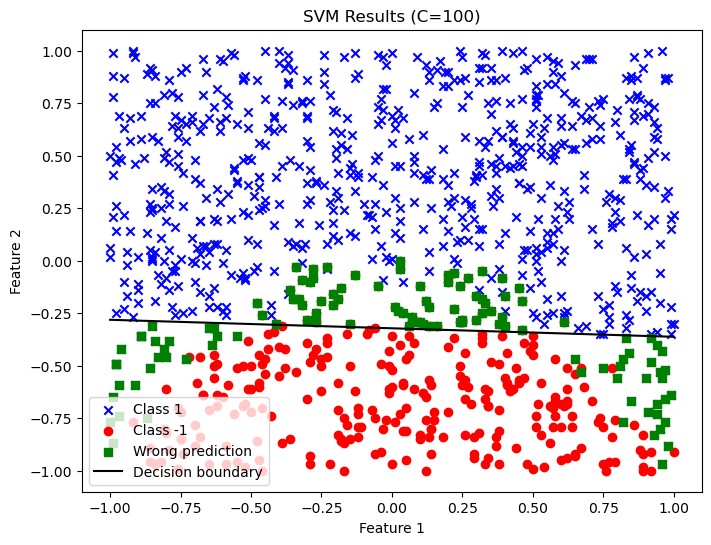

In [15]:
X1_sq = X1 ** 2
X2_sq = X2 ** 2
X_new = np.column_stack([X1, X2, X1_sq, X2_sq])


In [16]:
model_new = LogisticRegression()
model_new.fit(X_new, y)
print('Model coefficients:', model_new.coef_)
print('Model intercept:', model_new.intercept_)


Model coefficients: [[ 0.20734729  6.88316517  6.37382474 -0.99412647]]
Model intercept: [0.37035376]


In [17]:
y_pred_new = model_new.predict(X_new)


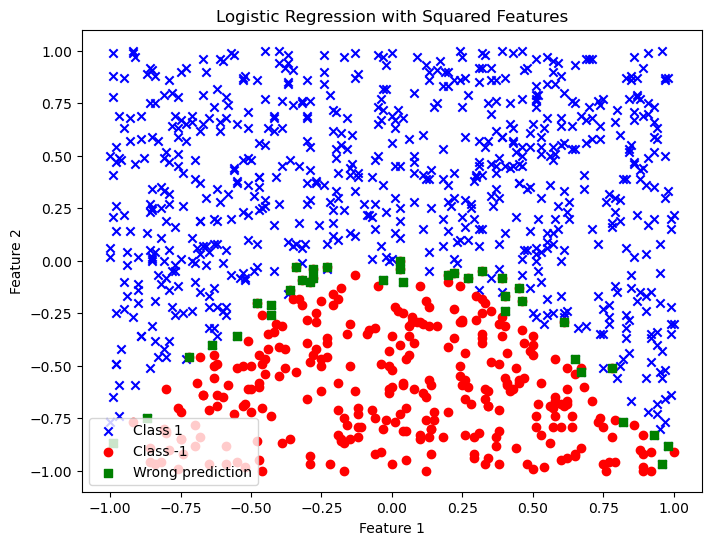

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(X1[y==1], X2[y==1], marker='x', color='blue', label='Class 1')
plt.scatter(X1[y==-1], X2[y==-1], marker='o', color='red', label='Class -1')
plt.scatter(X1[y_pred_new!=y], X2[y_pred_new!=y], marker='s', color='green', label='Wrong prediction')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Logistic Regression with Squared Features')
plt.show()


In [20]:
baseline = np.sign(np.sum(y)) 
baseline_pred = np.full_like(y, baseline)
baseline_accuracy = np.mean(baseline_pred == y)
print('Baseline accuracy:', baseline_accuracy)


Baseline accuracy: 0.6826826826826827
